# Source similarity

Construct bipartite graph:  
Nodes:  
- sources 
- Cantus IDs (CID)
Edges:
- edge between source and feast is present, if some chants dedicated to such feast are present in the catalogued source
- edge weight == log2(number of chants with unique CIDs)

Run SBM for weighted graph - try both basic and nested PLUS degree corrected versions.

In [1]:
import utils

In [2]:
import pycantus
import pycantus.data as data

In [3]:
corpus = data.load_dataset('cantuscorpus_v1.0')

Loading chants and sources...
Data loaded!


In [4]:
n_chants = len(corpus.chants)
print(f'Number of chants in CantusCorpus v1.0: {n_chants}')
n_sources = len(corpus.sources)
print(f'Number of sources in CantusCorpus v1.0: {n_sources}')

Number of chants in CantusCorpus v1.0: 888010
Number of sources in CantusCorpus v1.0: 2278


In [5]:
# Drop doxology
doxo_filter = pycantus.filtration.Filter('doxo_filter')
doxo_filter.add_value_exclude('cantus_id', '909000')
corpus.apply_filter(doxo_filter)

In [6]:
MIN_CHANTS_PER_SOURCE = 100

In [7]:
# Drop fragments => sources with less than 100 chants
corpus.drop_small_sources_data(min_chants=MIN_CHANTS_PER_SOURCE)

In [8]:
n_chants = len(corpus.chants)
print(f'Number of chants in CantusCorpus v1.0: {n_chants}')
n_sources = len(corpus.sources)
print(f'Number of sources in CantusCorpus v1.0: {n_sources}')

Number of chants in CantusCorpus v1.0: 855146
Number of sources in CantusCorpus v1.0: 510


Create network

In [11]:
import importlib
importlib.reload(utils)

<module 'utils' from '/home/ana/Desktop/ChantNets/experiments/utils.py'>

In [12]:
graph = utils.construct_bipart_source_feast_graph(corpus)

Constructing bipartite graph between sources and feasts...
Number of source nodes: 507
Number of feast nodes: 2371
Number of source-feast edges: 65700


In [13]:
print(f'Number of vertices: {graph.num_vertices()}')
print(f'Number of edges: {graph.num_edges()}')

Number of vertices: 2878
Number of edges: 65700


In [14]:
utils.save_graph(graph, f"nets/source_feast_bi_graph_min_{MIN_CHANTS_PER_SOURCE}.gt")

### Add SBM

In [15]:
import sbmodel
importlib.reload(sbmodel)

<module 'sbmodel' from '/home/ana/Desktop/ChantNets/experiments/sbmodel.py'>

In [16]:
model = sbmodel.SBModel()
model.load_graph(f"nets/source_feast_bi_graph_min_{MIN_CHANTS_PER_SOURCE}.gt")

Loaded graph with 2878 vertices, 65700 edges


In [17]:
N_INIT = 20

In [17]:
model.fit_sbm(n_init=N_INIT)

Fitting SBM to graph with 2878 vertices and 65700 edges...
Fitting SBM (init 1/20)...
[1/20] entropy = 135191.61
Fitting SBM (init 2/20)...
[2/20] entropy = 135103.74
Fitting SBM (init 3/20)...
[3/20] entropy = 134982.30
Fitting SBM (init 4/20)...
[4/20] entropy = 134995.46
Fitting SBM (init 5/20)...
[5/20] entropy = 135048.07
Fitting SBM (init 6/20)...
[6/20] entropy = 135115.29
Fitting SBM (init 7/20)...
[7/20] entropy = 135006.42
Fitting SBM (init 8/20)...
[8/20] entropy = 135047.82
Fitting SBM (init 9/20)...
[9/20] entropy = 134808.75
Fitting SBM (init 10/20)...
[10/20] entropy = 134973.93
Fitting SBM (init 11/20)...
[11/20] entropy = 134732.11
Fitting SBM (init 12/20)...
[12/20] entropy = 135100.21
Fitting SBM (init 13/20)...
[13/20] entropy = 135308.41
Fitting SBM (init 14/20)...
[14/20] entropy = 134833.98
Fitting SBM (init 15/20)...
[15/20] entropy = 134888.30
Fitting SBM (init 16/20)...
[16/20] entropy = 134842.64
Fitting SBM (init 17/20)...
[17/20] entropy = 134922.70
Fitting

In [18]:
model.save_states(f"models/dc_sbm_model_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle")

In [19]:
model.fit_nested_sbm(n_init=N_INIT)

Fitting nested SBM to graph with 2878 vertices and 65700 edges...
Fitting nested SBM (init 1/20)...
[1/20] entropy = 130669.70
Fitting nested SBM (init 2/20)...
[2/20] entropy = 130603.30
Fitting nested SBM (init 3/20)...
[3/20] entropy = 130546.40
Fitting nested SBM (init 4/20)...
[4/20] entropy = 130560.21
Fitting nested SBM (init 5/20)...
[5/20] entropy = 130591.96
Fitting nested SBM (init 6/20)...
[6/20] entropy = 131118.01
Fitting nested SBM (init 7/20)...
[7/20] entropy = 130569.54
Fitting nested SBM (init 8/20)...
[8/20] entropy = 130756.62
Fitting nested SBM (init 9/20)...
[9/20] entropy = 131074.17
Fitting nested SBM (init 10/20)...
[10/20] entropy = 130699.37
Fitting nested SBM (init 11/20)...
[11/20] entropy = 130816.68
Fitting nested SBM (init 12/20)...
[12/20] entropy = 130679.86
Fitting nested SBM (init 13/20)...
[13/20] entropy = 130309.30
Fitting nested SBM (init 14/20)...
[14/20] entropy = 130788.13
Fitting nested SBM (init 15/20)...
[15/20] entropy = 130620.38
Fitting

In [20]:
model.save_states(f"models/nested_dc_sbm_model_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle")

In [ ]:
model.fit_sbm_weighted(weight_label = "weight", n_init = N_INIT)
model.save_states(f"models/weighted_dc_sbm_model_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle")

Fitting weighted SBM to graph with 2878 vertices and 65700 edges...
Fitting weighted SBM (init 1/20)...
[1/20] entropy = 216534.96
Fitting weighted SBM (init 2/20)...
[2/20] entropy = 216131.86
Fitting weighted SBM (init 3/20)...
[3/20] entropy = 216839.80
Fitting weighted SBM (init 4/20)...
[4/20] entropy = 215759.10
Fitting weighted SBM (init 5/20)...
[5/20] entropy = 216127.03
Fitting weighted SBM (init 6/20)...
[6/20] entropy = 216204.13
Fitting weighted SBM (init 7/20)...
[7/20] entropy = 216470.51
Fitting weighted SBM (init 8/20)...
[8/20] entropy = 216439.65
Fitting weighted SBM (init 9/20)...
[9/20] entropy = 216271.96
Fitting weighted SBM (init 10/20)...
[10/20] entropy = 217041.36
Fitting weighted SBM (init 11/20)...
[11/20] entropy = 217261.23
Fitting weighted SBM (init 12/20)...
[12/20] entropy = 215781.30
Fitting weighted SBM (init 13/20)...
[13/20] entropy = 216515.50
Fitting weighted SBM (init 14/20)...
[14/20] entropy = 216338.28
Fitting weighted SBM (init 15/20)...
[15

## Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sbmodel import SBModel


def load_models(paths):
    """
    Load models and return entropy traces.
    """
    out = {}
    for name, path in paths.items():
        m = SBModel()
        m.load_states(path)
        #print(m.states)
        out[name] = [float(e['model']) for e in m.get_states()[name]]
    print(f"Loaded models: {list(out.keys())}")
    print(f"Number of runs per model: {[len(vals) for vals in out.values()]}")
    return out


def compute_log_odds(entropies):
    """
    Convert entropies to log-likelihood odds.
    """
    sigma_min = min(v for runs in entropies.values() for v in runs)
    return {
        m: [(val - sigma_min) * -np.log10(2.0) for val in vals]
        for m, vals in entropies.items()
    }


def plot_model_comparison(log_odds, out_path):
    """
    Plot log-likelihood differences across models.
    """
    cmap = plt.colormaps['Dark2']
    colours = {m: cmap(i / len(log_odds)) for i, m in enumerate(log_odds)}

    fig, ax = plt.subplots(figsize = (10, 2), constrained_layout = True)
    ax.axhline(0, color='black', linewidth=1)

    for model, xs in log_odds.items():
        ax.scatter(xs, np.zeros_like(xs), s=60, zorder=3, color=colours[model], alpha=0.3)

    for model, xs in log_odds.items():
        ax.text(np.median(xs), 0.14, model, ha='center', va='bottom', fontsize=12, color=colours[model])

    all_vals = np.concatenate(list(log_odds.values()))
    ticks = np.arange(
        int(200 * np.floor(all_vals.min() / 200)),
        int(200 * np.ceil(all_vals.max() / 200)) + 1, 200
    )
    for t in ticks:
        ax.plot([t, t], [-0.06, 0.06], color='black', linewidth=0.5)

    ax.set_yticks([])
    ax.set_xlim(left=min(0, all_vals.min() - 100), right=all_vals.max() + 100)
    ax.set_xlabel("Log10 odds relative to best model (×200)")

    fig.savefig(out_path, dpi = 300, bbox_inches = "tight")

Loaded models: ['DC_SBM', 'Nested_DC_SBM']
Number of runs per model: [20, 20]


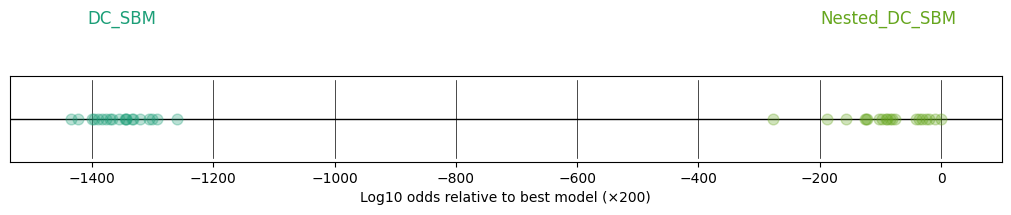

In [25]:
import os
os.makedirs("visual", exist_ok = True)

model_paths = {
    "DC_SBM": f"models/dc_sbm_model_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle",
    "Nested_DC_SBM": f"models/nested_dc_sbm_model_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle"
}

entropies = load_models(model_paths)
log_odds = compute_log_odds(entropies)
plot_model_comparison(log_odds, f"visual/model_comparison_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pdf")